<a href="https://colab.research.google.com/github/Vaibhavpandey1709/Image_Categorization_using_CNN/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, Input
from tensorflow.keras.models import Sequential

In [ ]:

tf.__version__

'2.17.1'

In [ ]:

from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
print("X Train: {} \nX Test: {} \ny Train: {} \ny test: {}".format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))

X Train: (50000, 32, 32, 3) 
X Test: (10000, 32, 32, 3) 
y Train: (50000, 1) 
y test: (10000, 1)


In [ ]:

y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

In [ ]:

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size = 32
)

In [ ]:

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [ ]:
test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size = 32
)

In [ ]:

cnn = Sequential()

In [ ]:

cnn.add(Input(shape=(32, 32, 3)))

In [ ]:

cnn.add(Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), activation="relu"))

In [ ]:
cnn.add(MaxPool2D(pool_size=(2,2), strides=2))

In [ ]:
cnn.add(Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), activation="relu"))

In [ ]:
cnn.add(MaxPool2D(pool_size=(2,2), strides=2))

In [ ]:
cnn.add(Flatten())

In [ ]:
cnn.add(Dense(units=128, activation="relu"))

In [ ]:
cnn.add(Dense(units=64, activation="relu"))

In [ ]:
cnn.add(Dense(units=10, activation="softmax"))

In [ ]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy", "precision", "recall", "f1_score"])

In [ ]:
history = cnn.fit(
    train_generator,
    epochs=25,
    validation_data=test_generator
)

Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 115s 72ms/step - accuracy: 0.3653 - f1_score: 0.3556 - loss: 1.7279 - precision: 0.6208 - recall: 0.1320 - val_accuracy: 0.5705 - val_f1_score: 0.5577 - val_loss: 1.1915 - val_precision: 0.7323 - val_recall: 0.4012
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 111s 71ms/step - accuracy: 0.5792 - f1_score: 0.5762 - loss: 1.1920 - precision: 0.7423 - recall: 0.4128 - val_accuracy: 0.5925 - val_f1_score: 0.5870 - val_loss: 1.1443 - val_precision: 0.7366 - val_recall: 0.4469
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 108s 69ms/step - accuracy: 0.6215 - f1_score: 0.6188 - loss: 1.0656 - precision: 0.7583 - recall: 0.4821 - val_accuracy: 0.6412 - val_f1_score: 0.6265 - val_loss: 1.0249 - val_precision: 0.7441 - val_recall: 0.5413
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 111s 71ms/step - accuracy: 0.6561 - f1_score: 0.6546 - loss: 0.9759 - precision: 0.7751 - recall: 0.5375 - val_accuracy: 0.6841 - val_f1_score: 0.6762 - val_loss: 0.9045 - val_precision: 0.7832 - va

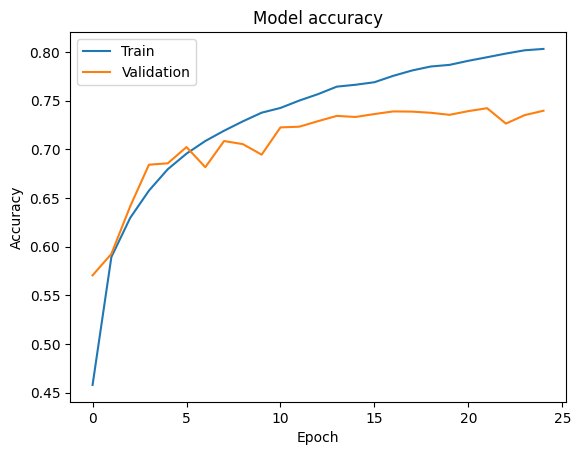

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()